# 02. Estatística Inferencial Aplicada a NPS

## 2. Exemplo Prático — NPS

Nesta seção, construiremos um fluxo completo de análise estatística aplicada a NPS.

O objetivo não é apenas executar código, mas entender:

- por que cada técnica é utilizada  
- o que ela revela sobre os dados  
- como isso impacta decisões estatísticas  

---

## 2.1 Geração da base de dados

Antes de trabalhar com inferência, precisamos de uma população.

Neste caso, vamos simular um cenário realista de NPS:

- muitos clientes satisfeitos (notas altas)
- alguns clientes neutros
- poucos clientes insatisfeitos

Isso gera uma distribuição **não perfeitamente normal**, o que é comum em dados reais.

In [1]:
# CÉLULA 1 — IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

In [2]:
# CÉLULA 2 — POPULAÇÃO NPS

grupo_alto = np.random.normal(loc=9.2, scale=0.8, size=6000)
grupo_medio = np.random.normal(loc=6.5, scale=1.2, size=2500)
grupo_baixo = np.random.normal(loc=2.5, scale=1.5, size=1500)

notas = np.concatenate([grupo_alto, grupo_medio, grupo_baixo])

notas = np.clip(notas, 0, 10)
notas = np.round(notas).astype(int)

df_pop = pd.DataFrame({
    "nps": notas
})

df_pop.head()

,nps
0,10
1,9
2,10
3,10
4,9


## 2.2 Análise exploratória (EDA)

Antes de qualquer inferência, precisamos entender **como os dados se comportam**.

### 2.2.1 Estatísticas descritivas

As estatísticas resumem a distribuição em números:

- média → tendência central  
- mediana → robusta a outliers  
- desvio padrão → dispersão  
- assimetria → inclinação da distribuição  
- curtose → concentração de caudas  

In [3]:
# CÉLULA 3 — ESTATÍSTICAS

media_pop = df_pop["nps"].mean()
mediana_pop = df_pop["nps"].median()
desvio_pop = df_pop["nps"].std()

assimetria = stats.skew(df_pop["nps"])
curtose = stats.kurtosis(df_pop["nps"])

print(f"Média: {media_pop:.3f}")
print(f"Mediana: {mediana_pop:.3f}")
print(f"Desvio padrão: {desvio_pop:.3f}")
print(f"Assimetria: {assimetria:.3f}")
print(f"Curtose: {curtose:.3f}")

Média: 7.489
Mediana: 8.000
Desvio padrão: 2.580
Assimetria: -1.166
Curtose: 0.421


### 2.2.2 Histograma

O histograma mostra **a forma da distribuição**.

Ele responde perguntas como:

- os dados são simétricos?
- existem múltiplos picos?
- há concentração em determinados valores?

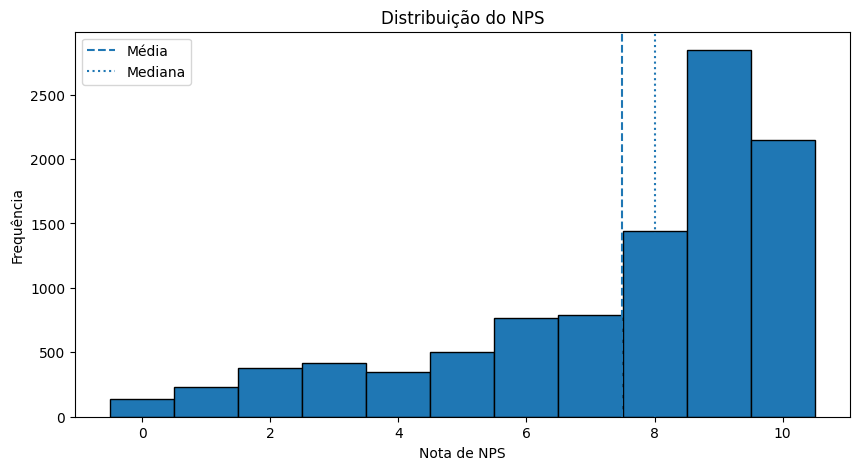

In [4]:
# CÉLULA 4 — HISTOGRAMA

plt.figure(figsize=(10, 5))

plt.hist(df_pop["nps"], bins=np.arange(-0.5, 11.5, 1), edgecolor="black")

plt.axvline(media_pop, linestyle="--", label="Média")
plt.axvline(mediana_pop, linestyle=":", label="Mediana")

plt.legend()
plt.title("Distribuição do NPS")
plt.xlabel("Nota de NPS")
plt.ylabel("Frequência")

plt.show()

> **Leitura esperada:** em NPS, é comum observar concentração em notas altas, gerando assimetria.

### 2.2.3 Boxplot

O boxplot é utilizado para:

- identificar outliers  
- visualizar dispersão  
- entender quartis  

Ele é essencial porque outliers impactam diretamente inferência.

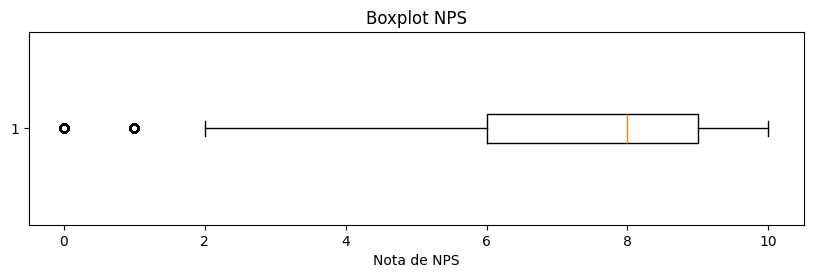

In [5]:
# CÉLULA 5 — BOXPLOT

plt.figure(figsize=(10, 2.5))

plt.boxplot(df_pop["nps"], vert=False)

plt.title("Boxplot NPS")
plt.xlabel("Nota de NPS")

plt.show()

### 2.2.4 Q-Q Plot

O Q-Q plot compara a distribuição dos dados com uma normal.

Ele responde:

- os dados seguem uma distribuição normal?
- há desvios nas caudas?

Se os pontos seguem uma linha reta, os dados estão mais próximos da normalidade.

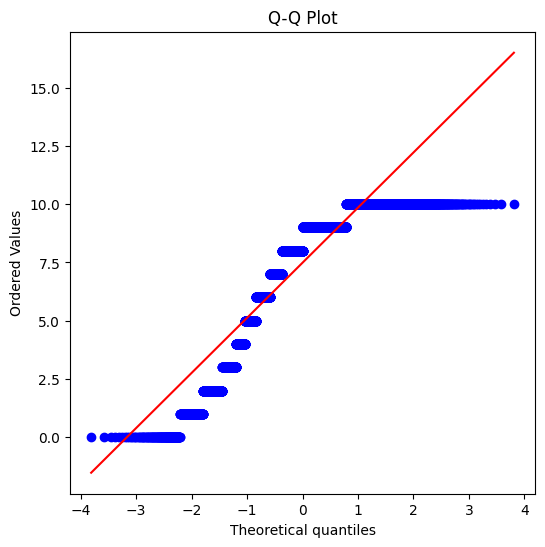

In [6]:
# CÉLULA 6 — Q-Q PLOT

plt.figure(figsize=(6, 6))

stats.probplot(df_pop["nps"], dist="norm", plot=plt)

plt.title("Q-Q Plot")

plt.show()

### 2.2.5 Teste de normalidade (Shapiro-Wilk)

O teste de Shapiro-Wilk avalia formalmente se os dados seguem uma distribuição normal.

- **H0**: os dados são normais  
- **H1**: os dados não são normais  

Como a população é grande, usamos apenas uma subamostra para o teste.

In [7]:
# CÉLULA 7 — SHAPIRO

amostra_shapiro = df_pop["nps"].sample(500, random_state=42)

stat, p = stats.shapiro(amostra_shapiro)

print(f"Estatística: {stat:.4f}")
print(f"p-valor: {p:.6f}")

Estatística: 0.8464
p-valor: 0.000000


> **Leitura correta:** se `p < 0.05`, rejeitamos a hipótese de normalidade.

## 2.3 Processo de amostragem

Na prática, quase nunca temos acesso à população completa.

Então coletamos uma amostra e tentamos inferir sobre o todo.

In [8]:
# CÉLULA 8 — AMOSTRA

amostra = df_pop.sample(n=80, random_state=123)

amostra.head()

,nps
2656,8
445,10
9505,4
332,9
4168,10


### Comparação população vs amostra

Aqui avaliamos se a amostra representa razoavelmente a população.

In [9]:
# CÉLULA 9 — COMPARAÇÃO

print(f"Média da população: {media_pop:.3f}")
print(f"Média da amostra: {amostra['nps'].mean():.3f}")

Média da população: 7.489
Média da amostra: 7.775


### Histograma da amostra

Serve para comparar visualmente:

- a forma da amostra  
- diferenças em relação à população  

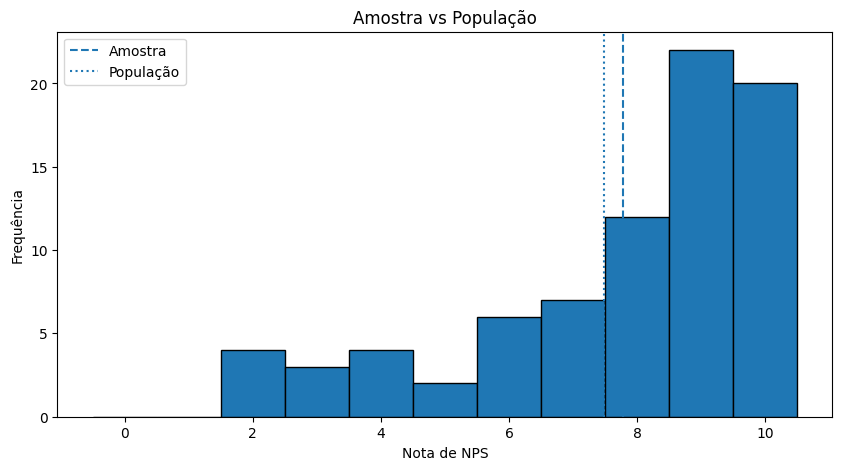

In [10]:
# CÉLULA 10 — HISTOGRAMA AMOSTRA

plt.figure(figsize=(10, 5))

plt.hist(amostra["nps"], bins=np.arange(-0.5, 11.5, 1), edgecolor="black")

plt.axvline(amostra["nps"].mean(), linestyle="--", label="Amostra")
plt.axvline(media_pop, linestyle=":", label="População")

plt.legend()
plt.title("Amostra vs População")
plt.xlabel("Nota de NPS")
plt.ylabel("Frequência")

plt.show()

## 2.4 Distribuição amostral

Aqui entra o conceito mais importante da inferência:

> o comportamento da média amostral ao repetir o processo.

Mesmo que os dados originais não sejam perfeitamente normais, a média tende a se estabilizar.

In [11]:
# CÉLULA 11 — SIMULAÇÃO

medias = []

for _ in range(5000):
    temp = df_pop["nps"].sample(n=80)
    medias.append(temp.mean())

medias = np.array(medias)

print(f"Média das médias amostrais: {medias.mean():.3f}")
print(f"Desvio padrão das médias amostrais: {medias.std():.3f}")

Média das médias amostrais: 7.490
Desvio padrão das médias amostrais: 0.296


### Histograma das médias

Este gráfico mostra:

- variabilidade da média  
- aproximação da normalidade  
- evidência prática do Teorema Central do Limite  

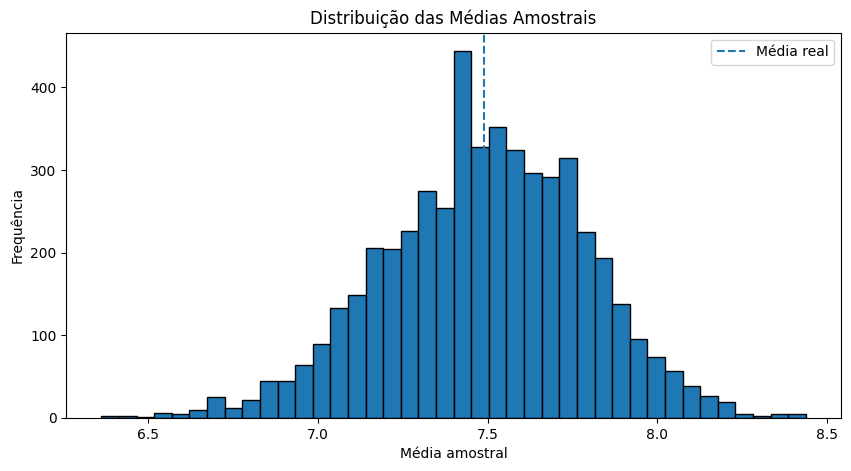

In [12]:
# CÉLULA 12 — HISTOGRAMA MÉDIAS

plt.figure(figsize=(10, 5))

plt.hist(medias, bins=40, edgecolor="black")

plt.axvline(media_pop, linestyle="--", label="Média real")

plt.legend()
plt.title("Distribuição das Médias Amostrais")
plt.xlabel("Média amostral")
plt.ylabel("Frequência")

plt.show()

## 2.5 Intervalo de confiança (t-Student)

Agora usamos a amostra para estimar a média da população.

A lógica é:

- estimar a média  
- calcular o erro padrão  
- usar a distribuição t de Student  
- construir a faixa plausível da média populacional  

In [13]:
# CÉLULA 13 — IC T-STUDENT

n = len(amostra)
media = amostra["nps"].mean()
desvio = amostra["nps"].std(ddof=1)

erro = desvio / np.sqrt(n)

t = stats.t.ppf(0.975, df=n-1)

margem = t * erro

ic_inf = media - margem
ic_sup = media + margem

print(f"Média amostral: {media:.3f}")
print(f"Erro padrão: {erro:.3f}")
print(f"IC 95%: ({ic_inf:.3f}, {ic_sup:.3f})")

Média amostral: 7.775
Erro padrão: 0.261
IC 95%: (7.256, 8.294)


> **Interpretação:** o intervalo representa uma faixa plausível para a média real da população.

---

## 2.6 Cenário problemático (violação de premissas)

Até aqui, trabalhamos com uma amostra relativamente bem comportada.

Agora vamos simular um cenário mais realista — e mais perigoso:

- amostra pequena  
- presença de outliers  
- forte assimetria  

Esse é exatamente o tipo de situação onde muitos analistas aplicam métodos clássicos de forma incorreta.

In [14]:
# CÉLULA 14 — AMOSTRA PROBLEMÁTICA

amostra_ruim = pd.DataFrame({
    "nps": [10, 10, 9, 10, 8, 9, 10, 9, 10, 10, 2, 1, 0, 10, 9]
})

amostra_ruim

,nps
0,10
1,10
2,9
3,10
4,8
5,9
6,10
7,9
8,10
9,10


### 2.6.1 Diagnóstico estatístico

Antes de aplicar qualquer método, precisamos avaliar:

- tamanho da amostra  
- assimetria  
- presença de outliers  
- normalidade  

In [15]:
# CÉLULA 15 — DIAGNÓSTICO

n_ruim = len(amostra_ruim)

media_ruim = amostra_ruim["nps"].mean()
desvio_ruim = amostra_ruim["nps"].std()

assimetria_ruim = stats.skew(amostra_ruim["nps"])
curtose_ruim = stats.kurtosis(amostra_ruim["nps"])

stat, p_valor = stats.shapiro(amostra_ruim["nps"])

print(f"Tamanho: {n_ruim}")
print(f"Média: {media_ruim:.3f}")
print(f"Desvio: {desvio_ruim:.3f}")
print(f"Assimetria: {assimetria_ruim:.3f}")
print(f"Curtose: {curtose_ruim:.3f}")
print(f"p-valor (Shapiro): {p_valor:.6f}")

Tamanho: 15
Média: 7.800
Desvio: 3.590
Assimetria: -1.443
Curtose: 0.293
p-valor (Shapiro): 0.000064


### 2.6.2 Análise visual

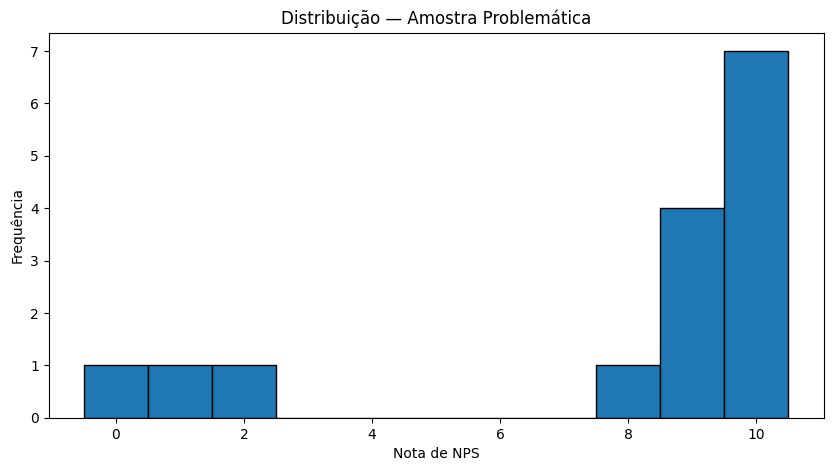

In [16]:
# CÉLULA 16 — HISTOGRAMA PROBLEMÁTICO

plt.figure(figsize=(10, 5))

plt.hist(amostra_ruim["nps"], bins=np.arange(-0.5, 11.5, 1), edgecolor="black")

plt.title("Distribuição — Amostra Problemática")
plt.xlabel("Nota de NPS")
plt.ylabel("Frequência")

plt.show()

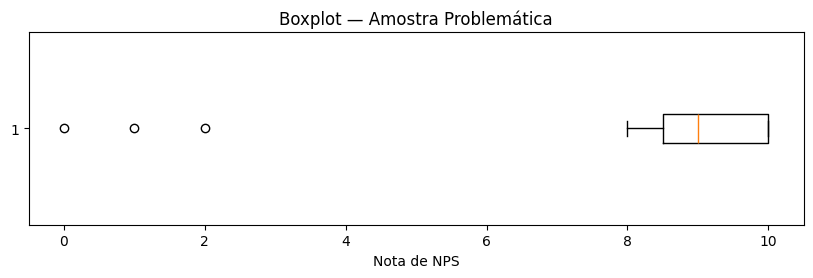

In [17]:
# CÉLULA 17 — BOXPLOT PROBLEMÁTICO

plt.figure(figsize=(10, 2.5))

plt.boxplot(amostra_ruim["nps"], vert=False)

plt.title("Boxplot — Amostra Problemática")
plt.xlabel("Nota de NPS")

plt.show()

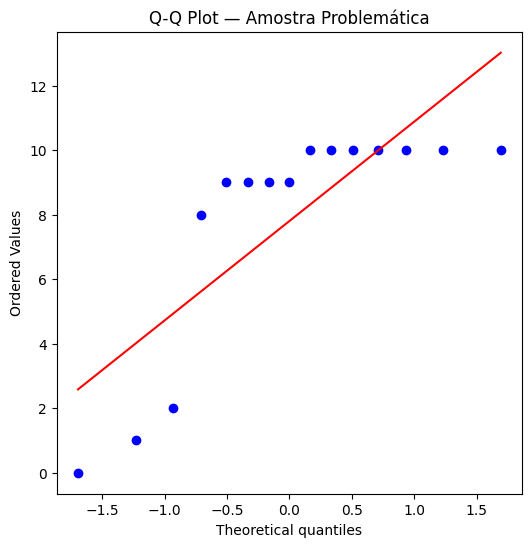

In [18]:
# CÉLULA 18 — Q-Q PLOT PROBLEMÁTICO

plt.figure(figsize=(6, 6))

stats.probplot(amostra_ruim["nps"], dist="norm", plot=plt)

plt.title("Q-Q Plot — Amostra Problemática")

plt.show()

> **Diagnóstico crítico:**

- `n` é pequeno  
- há outliers  
- há assimetria  
- há forte indício de não normalidade  

Isso enfraquece as premissas do t-Student.

## 2.7 Aplicando t-Student mesmo assim

Mesmo com problemas, vamos calcular o intervalo para entender o comportamento.

In [19]:
# CÉLULA 19 — IC T-STUDENT PROBLEMÁTICO

n = len(amostra_ruim)
media = amostra_ruim["nps"].mean()
desvio = amostra_ruim["nps"].std(ddof=1)

erro = desvio / np.sqrt(n)

t = stats.t.ppf(0.975, df=n-1)

margem = t * erro

ic_inf_t = media - margem
ic_sup_t = media + margem

print(f"IC t-Student: ({ic_inf_t:.3f}, {ic_sup_t:.3f})")

IC t-Student: (5.812, 9.788)


> **Problema conceitual:** o t-Student assume normalidade aproximada e baixa influência de outliers. Aqui essas condições não são atendidas.

## 2.8 Bootstrap

Bootstrap contorna esse problema ao:

- não assumir distribuição específica  
- usar reamostragem empírica  
- construir a distribuição diretamente dos dados  

### 2.8.1 Intuição

> Em vez de confiar apenas em uma fórmula teórica, usamos os próprios dados para simular o comportamento da média.

In [20]:
# CÉLULA 20 — BOOTSTRAP

n_boot = 10000

medias_boot = []

for _ in range(n_boot):
    reamostra = amostra_ruim["nps"].sample(n=len(amostra_ruim), replace=True)
    medias_boot.append(reamostra.mean())

medias_boot = np.array(medias_boot)

### 2.8.2 Intervalo bootstrap

In [21]:
# CÉLULA 21 — IC BOOTSTRAP

ic_inf_boot = np.percentile(medias_boot, 2.5)
ic_sup_boot = np.percentile(medias_boot, 97.5)

print(f"IC Bootstrap: ({ic_inf_boot:.3f}, {ic_sup_boot:.3f})")

IC Bootstrap: (5.933, 9.400)


### 2.8.3 Visualização

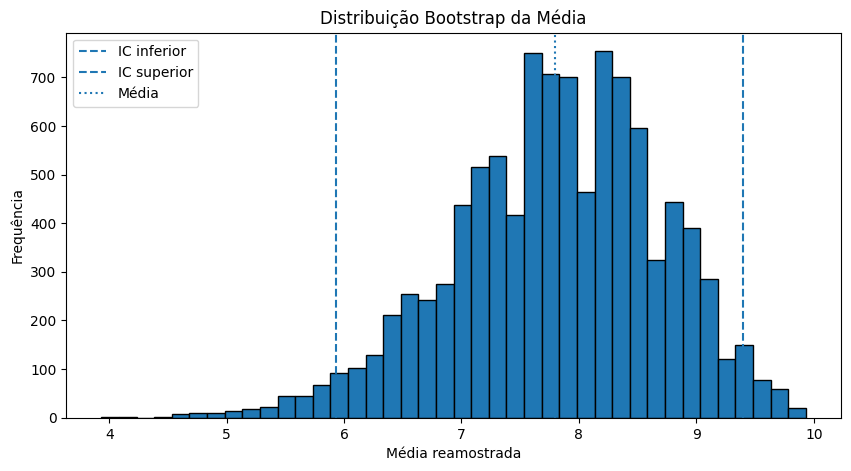

In [22]:
# CÉLULA 22 — DISTRIBUIÇÃO BOOTSTRAP

plt.figure(figsize=(10, 5))

plt.hist(medias_boot, bins=40, edgecolor="black")

plt.axvline(ic_inf_boot, linestyle="--", label="IC inferior")
plt.axvline(ic_sup_boot, linestyle="--", label="IC superior")
plt.axvline(media_ruim, linestyle=":", label="Média")

plt.legend()
plt.title("Distribuição Bootstrap da Média")
plt.xlabel("Média reamostrada")
plt.ylabel("Frequência")

plt.show()

## 2.9 Comparação entre métodos

Agora comparamos diretamente os dois intervalos.

In [23]:
# CÉLULA 23 — COMPARAÇÃO

comparacao = pd.DataFrame({
    "metodo": ["t-Student", "Bootstrap"],
    "limite_inferior": [ic_inf_t, ic_inf_boot],
    "limite_superior": [ic_sup_t, ic_sup_boot],
    "largura": [ic_sup_t - ic_inf_t, ic_sup_boot - ic_inf_boot]
})

comparacao

,metodo,limite_inferior,limite_superior,largura
0,t-Student,5.812108,9.787892,3.975783
1,Bootstrap,5.933333,9.400000,3.466667


### Interpretação profissional

- se os intervalos forem muito diferentes, há sinal de instabilidade  
- bootstrap tende a refletir melhor a realidade em cenários não ideais  
- t-Student pode subestimar ou superestimar o erro  

## 2.10 Tomada de decisão

Agora entramos no ponto mais importante da análise:

> escolher o método correto com base nos dados.

In [24]:
# CÉLULA 24 — DECISÃO

n_pequeno = len(amostra_ruim) < 30
assimetria_alta = abs(assimetria_ruim) > 1
nao_normal = p_valor < 0.05

print("Amostra pequena:", n_pequeno)
print("Alta assimetria:", assimetria_alta)
print("Não normal:", nao_normal)

if n_pequeno and (assimetria_alta or nao_normal):
    print("Recomendação: usar Bootstrap")
else:
    print("Recomendação: t-Student é suficiente")

Amostra pequena: True
Alta assimetria: True
Não normal: True
Recomendação: usar Bootstrap


### 2.10.1 Interpretação de negócio

A escolha do método impacta diretamente:

- risco da decisão  
- confiança nos resultados  
- custo de erro  

> **Regra de ouro:** estatística não é sobre aplicar fórmulas. É sobre entender os dados e escolher o método adequado.

---

## 2.11 Conclusão

Neste exemplo prático, percorremos um fluxo completo:

- geração de população  
- amostragem  
- distribuição amostral  
- intervalo com t-Student  
- diagnóstico de premissas  
- cenário problemático  
- bootstrap  
- comparação de métodos  
- decisão final  

Esse fluxo representa o padrão esperado de um analista ou cientista de dados em ambiente profissional.

---

## Referências

- Efron, B.; Tibshirani, R. (1993). *An Introduction to the Bootstrap*  
- Casella, G.; Berger, R. (2002). *Statistical Inference*  
- Montgomery, D. (2014). *Applied Statistics*  
- Bruce, P.; Bruce, A.; Gedeck, P. (2020). *Practical Statistics for Data Scientists*  